# Imports

In [1]:
import re
from pathlib import Path

import feat_select as fs
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.io as sio
from matplotlib import pyplot as plt
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
from sklearn import tree

# Read Scores

In [2]:
final_perf_scores = pd.read_parquet(
    Path("../datasets/catch_22/checkpoints/final_perf_scores_all_features.parquet")
)
CATCH22 = [
    "DN_HistogramMode_5",
    "DN_HistogramMode_10",
    "SB_BinaryStats_mean_longstretch1",
    "DN_OutlierInclude_p_001_mdrmd",
    "DN_OutlierInclude_n_001_mdrmd",
    # "CO_f1ecac",
    # "CO_FirstMin_ac",
    "SP_Summaries_welch_rect_area_5_1",
    "SP_Summaries_welch_rect_centroid",
    "FC_LocalSimple_mean3_stderr",
    "CO_trev_1_num",
    "CO_HistogramAMI_even_2_5",
    "IN_AutoMutualInfoStats_40_gaussian_fmmi",
    "MD_hrv_classic_pnn40",
    "SB_BinaryStats_diff_longstretch0",
    "SB_MotifThree_quantile_hh",
    "FC_LocalSimple_mean1_tauresrat",
    "CO_Embed2_Dist_tau_d_expfit_meandiff",
    "SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1",
    "SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1",
    "SB_TransitionMatrix_3ac_sumdiagcov",
    "PD_PeriodicityWang_th0.01",
]

# Paper Level 1 Validation - Mean Balanced Accuracy per dataset
- "Using the diverse canonical catch22 feature-subset, the mean class-balanced accuracy across all datasets, $a^{tot}$, of catch22 was ∼72%, a small reduction relative to the ∼77% achieved when computing all 4791 features. See Fig. 4A for a dataset-by-dataset scatter."
- accuracy of catch22 lower by a relative difference of 37% for the dataset 'EthanolLevel'; 50.2% full vs 31.8% catch22
- The reduced set gave better mean performance in only a small number of cases: e.g., for 'ECGMeditation' with 60% full vs 81.2% catch22; given that this dataset contained just 28 time series and had a high standard deviation in accuracies of the full set between folds (35.3%), the performance might not be significantly increased

In [ ]:

# c22_scores = new_perf_scores[CATCH22]
# c22_scores.groupby(["dataset_name"]).mean()

In [5]:
c22_scores.head()

,DN_HistogramMode_5,DN_HistogramMode_10,SB_BinaryStats_mean_longstretch1,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr,CO_trev_1_num,CO_HistogramAMI_even_2_5,IN_AutoMutualInfoStats_40_gaussian_fmmi,MD_hrv_classic_pnn40,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,FC_LocalSimple_mean1_tauresrat,CO_Embed2_Dist_tau_d_expfit_meandiff,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0.01
dataset_name,,,,,,,,,,,,,,,,,,,,
AALTDChallenge,0.286508,0.323016,0.224603,0.246825,0.249206,0.250000,0.358730,0.321429,0.142857,0.241270,0.388095,0.295238,0.214286,0.235714,0.282540,0.213492,0.384127,0.288889,0.302381,0.302381
Adiac,0.143243,0.297297,0.095495,0.114414,0.155856,0.127477,0.027027,0.134234,0.062162,0.153604,0.045946,0.154505,0.145045,0.044595,0.148198,0.306757,0.093243,0.114414,0.077027,0.029730
ArrowHead,0.647354,0.605357,0.590344,0.376455,0.465476,0.507407,0.406481,0.520172,0.350661,0.493915,0.561971,0.517063,0.389087,0.576720,0.532275,0.570966,0.391336,0.480357,0.547884,0.510185
Beef,0.360000,0.260000,0.410000,0.330000,0.330000,0.380000,0.340000,0.180000,0.240000,0.210000,0.200000,0.320000,0.360000,0.310000,0.430000,0.270000,0.390000,0.330000,0.320000,0.260000
BeetleFly,0.675000,0.600000,0.700000,0.525000,0.600000,0.425000,0.325000,0.775000,0.550000,0.650000,0.700000,0.700000,0.475000,0.700000,0.675000,0.725000,0.500000,0.625000,0.775000,0.575000


In [6]:
px.histogram(c22_scores.mean(axis=1))

In [7]:
c22_scores.mean(axis=1).mean()

np.float64(0.44311870293911715)

## Fit on C22 feature set


In [ ]:
TEST_DATASETS = ["EthanolLevel", "ECGMeditation"]

import re
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
import scipy.io as sio
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.metrics import balanced_accuracy_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_score


def calc_per_feat_score_v1(
    task_df: pd.DataFrame, nfolds: pd.DataFrame, feature_cols: Optional[List[str]] = None
) -> pd.DataFrame:
    if not feature_cols:
        feature_cols = [col for col in task_df.columns if col not in ["label", "dataset_name"]]

    actual_scores = {}

    def _score_feature(data, y, feature, cv, scorer):
        X = data[[feature]]
        # print(X.shape)
        # TODO: replace this with custom tree
        clf = tree.DecisionTreeClassifier(class_weight="balanced", random_state=23)
        return cross_val_score(clf, X, y, cv=cv, scoring=scorer).mean()

    datasets = list(task_df.groupby(["dataset_name"]))
    total = len(datasets)
    for i, ((dname,), data) in enumerate(datasets, 1):
        print(f"[{i}/{total}] {dname=}")
        n_cv = nfolds.loc[nfolds["dataset_name"] == dname, "nfolds"].values[0]
        cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=23)
        y = data["label"]
        actual_scores[dname] = Parallel(n_jobs=-1)(
            delayed(_score_feature)(data, y, feature, cv, make_scorer(balanced_accuracy_score))
            for feature in feature_cols
        )

    return pd.DataFrame.from_dict(actual_scores, orient="index", columns=feature_cols).rename_axis(
        "dataset_name"
    )


all_tasks_n_pf = pd.read_parquet(
    Path("../datasets/catch_22/checkpoints/ucr_tasks_feat_norm.parquet"),
    # filters=[("dataset_name", "in", TEST_DATASETS)],
)
nfolds = fs.num_of_folds(all_tasks_n_pf)
final_perf_scores = calc_per_feat_score_v1(all_tasks_n_pf, nfolds)  # feature_cols=TEST_FEATURES)
final_perf_scores.head()


[1/93] dname='AALTDChallenge'
[2/93] dname='Adiac'
[3/93] dname='ArrowHead'
[4/93] dname='Beef'
[5/93] dname='BeetleFly'
[6/93] dname='BirdChicken'
[7/93] dname='CBF'
[8/93] dname='Car'
[9/93] dname='ChlorineConcentration'
[10/93] dname='CinCECGtorso'
[11/93] dname='Coffee'
[12/93] dname='Computers'
[13/93] dname='CricketX'
[14/93] dname='CricketY'
[15/93] dname='CricketZ'
[16/93] dname='DiatomSizeReduction'
[17/93] dname='DistalPhalanxOutlineAgeGroup'
[18/93] dname='DistalPhalanxOutlineCorrect'
[19/93] dname='DistalPhalanxTW'
[20/93] dname='ECG200'
[21/93] dname='ECG5000'
[22/93] dname='ECGFiveDays'
[23/93] dname='ECGMeditation'
[24/93] dname='Earthquakes'
[25/93] dname='ElectricDeviceOn'
[26/93] dname='ElectricDevices'
[27/93] dname='EpilepsyX'
[28/93] dname='EthanolLevel'
[29/93] dname='FaceAll'
[30/93] dname='FaceFour'
[31/93] dname='FacesUCR'
[32/93] dname='FiftyWords'
[33/93] dname='Fish'
[34/93] dname='FordA'
[35/93] dname='FordB'
[36/93] dname='GunPoint'
[37/93] dname='Ham'
[38

,DN_HistogramMode_5,DN_HistogramMode_10,DN_HistogramMode_20,maximum,miminmum,DN_Moments_3,DN_Moments_4,DN_Moments_5,DN_Moments_6,DN_Moments_7,...,SD_SurrogateTest_RP_99_o3_p,SD_SurrogateTest_RP_99_o3_zscore,SD_SurrogateTest_RP_99_o3_f,SD_SurrogateTest_RP_99_o3_mediqr,SD_SurrogateTest_RP_99_o3_prank,SD_SurrogateTest_RP_99_tc3_p,SD_SurrogateTest_RP_99_tc3_zscore,SD_SurrogateTest_RP_99_tc3_f,SD_SurrogateTest_RP_99_tc3_mediqr,SD_SurrogateTest_RP_99_tc3_prank
dataset_name,,,,,,,,,,,,,,,,,,,,,
AALTDChallenge,0.316667,0.302381,0.259524,0.178571,0.183333,0.195238,0.225397,0.196032,0.199206,0.196825,...,0.145238,0.206349,0.145238,0.172222,0.142857,0.214286,0.204762,0.201587,0.251587,0.283333
Adiac,0.144595,0.292793,0.421622,0.118468,0.142793,0.146847,0.173874,0.134234,0.155405,0.153604,...,0.065766,0.076577,0.139640,0.051802,0.077928,0.137387,0.150901,0.191892,0.135135,0.170270
ArrowHead,0.660648,0.591799,0.514087,0.554630,0.453307,0.438360,0.569312,0.368717,0.490476,0.403770,...,0.345370,0.336905,0.411839,0.306746,0.337632,0.440741,0.455556,0.426455,0.428108,0.468717
Beef,0.310000,0.250000,0.240000,0.200000,0.350000,0.270000,0.300000,0.310000,0.260000,0.280000,...,0.140000,0.140000,0.370000,0.280000,0.230000,0.370000,0.320000,0.380000,0.300000,0.280000
BeetleFly,0.725000,0.625000,0.625000,0.525000,0.825000,0.850000,0.650000,0.825000,0.625000,0.850000,...,0.525000,0.400000,0.500000,0.425000,0.675000,0.500000,0.700000,0.500000,0.550000,0.625000


In [ ]:
# final_perf_scores.to_parquet(Path("../datasets/catch_22/checkpoints/final_perf_scores_all_features.parquet"))

# Clustering on final scores

In [3]:
random_perf_features = pd.read_csv(
    Path("../datasets/catch_22/checkpoints/catch22_insignificant_features_S1.txt"),
    comment="#",
    header=None,
    names=["p_value", "feature_name"],
)

# Get the list of features that performed no better than random
random_feature_names = random_perf_features["feature_name"].values

# Filter out random-performing features from the combined scores
final_perf_scores = final_perf_scores[
    [col for col in final_perf_scores.columns if col not in random_feature_names]
]

## Normalizing Raw Scores - to remove dataset complexity

In [25]:
row_std = final_perf_scores.std(axis=1).clip(lower=1e-8)
perf_scores_norm = final_perf_scores.sub(final_perf_scores.mean(axis=1), axis=0).div(row_std, axis=0)
stats = perf_scores_norm.mean() + perf_scores_norm.std()
cols_to_keep = stats[stats >= 0].index
perf_scores_norm = perf_scores_norm[cols_to_keep]
## combined accuracy per features
perf_scores_norm_comb = perf_scores_norm.mean()

perf_thresh = perf_scores_norm_comb.mean() + perf_scores_norm_comb.std()
top_performers = perf_scores_norm_comb[perf_scores_norm_comb >= perf_thresh]
top_performers.shape
print(perf_thresh, perf_scores_norm_comb.shape[0], top_performers.shape[0])

# Check that C22 features are present in top_performers
c22_in_top = [f for f in fs.CATCH22 if f in top_performers.index]
c22_missing = [f for f in fs.CATCH22 if f not in top_performers.index]

print(f"C22 features in top_performers: {len(c22_in_top)}/{len(fs.CATCH22)}")
if c22_missing:
    print(f"Missing from top_performers: {c22_missing}")
else:
    print("All C22 features are present in top_performers.")

0.4521267511922407 5956 898
C22 features in top_performers: 20/22
Missing from top_performers: ['CO_f1ecac', 'CO_FirstMin_ac']


23 clusters from 898 features
                                         feature  cluster
685                 SP_Summaries_welch_rect_maxw        1
317                     PD_PeriodicityWang_th0.2        1
702               SP_Summaries_welch_rect_w25_75        1
94   IN_AutoMutualInfoStats_40_gaussian_pextrema        1
697              SP_Summaries_welch_rect_wmax_75        1
..                                           ...      ...
48                      CO_HistogramAMI_std2_2_2       23
49                      CO_HistogramAMI_std2_2_3       23
50                      CO_HistogramAMI_std2_2_4       23
297              CO_Embed2_Basic_tau_parabup05_1       23
394                        SY_RangeEvolve_nuqp50       23

[898 rows x 2 columns]


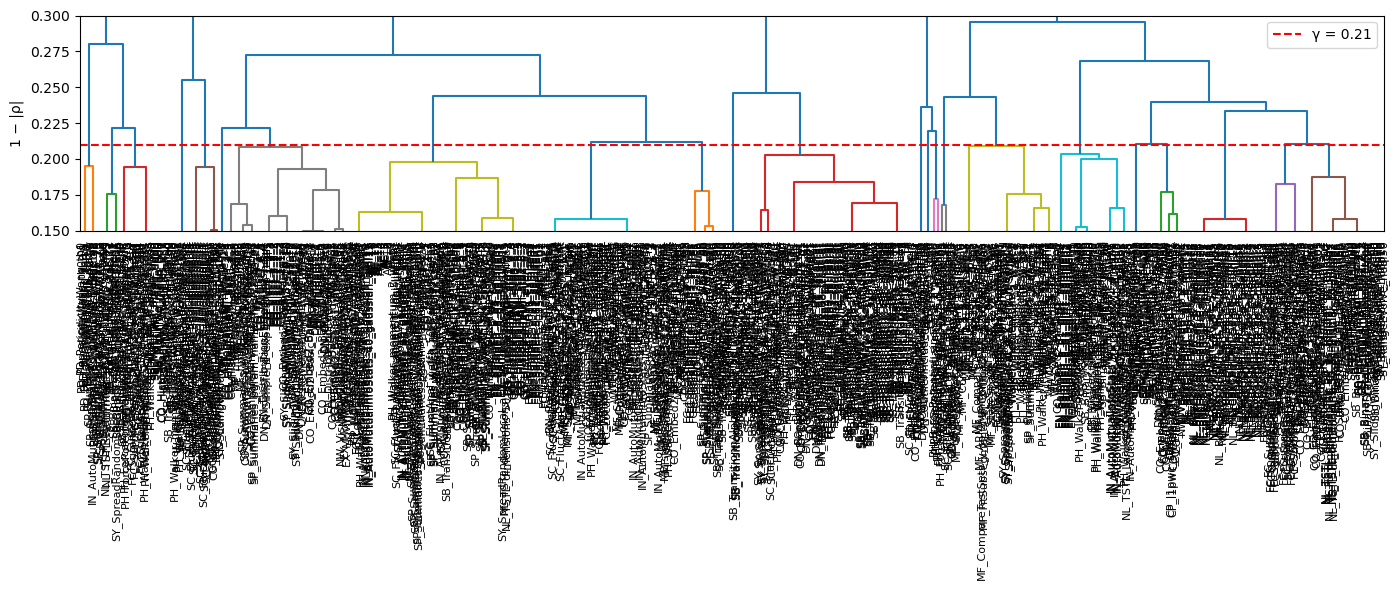

In [26]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform

nf = len(top_performers)
gamma = 0.21
# 1. absolute Pearson correlation → distance
corr = final_perf_scores[list(top_performers.index)[:nf]].corr()
dist = 1 - corr.abs().copy()
# np.fill_diagonal(dist.values, 0)          # ensure exact zeros on diagonal
dist = dist.clip(lower=0)  # handle floating-point negatives

# 2. condensed distance matrix (upper triangle, no diagonal)
condensed = squareform(dist, checks=False)

# 3. hierarchical clustering — complete linkage
Z = linkage(condensed, method="complete")

# 4. cut tree at distance threshold γ
clusters = fcluster(Z, t=gamma, criterion="distance")

# 5. summary
cluster_df = pd.DataFrame({"feature": list(top_performers.index)[:nf], "cluster": clusters})
print(f"{cluster_df['cluster'].nunique()} clusters from {len(cluster_df)} features")
print(cluster_df.sort_values("cluster"))

# 6. (optional) dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    labels=top_performers.index.tolist()[:nf],
    ax=ax,
    color_threshold=gamma,
    leaf_rotation=90,
    leaf_font_size=8,
)
ax.axhline(gamma, ls="--", color="red", label=f"γ = {gamma}")
ax.set_ylim(0.15, 0.3)
ax.set_ylabel("1 − |ρ|")
ax.legend()
plt.tight_layout()
plt.show()

## plot cluster scores


In [79]:
# score_df = final_perf_scores
acc_mean = {}
acc_z_score = {}
c22_acc_mean = {}
c22_acc_z_score = {}

# for cluster, df in cluster_df.groupby("cluster"):
#     cluster_scores = score_df[df["feature"]]                  # datasets × features
#     row_mean = cluster_scores.mean(axis=1)                     # mean across features per dataset
#     normalized = cluster_scores.div(row_mean, axis=0)          # normalize per dataset
#     mean_accuracy[cluster] = normalized.mean(axis=0)           # mean across datasets per feature

#     # Collect CATCH22 features in this cluster
#     c22_in_cluster = [f for f in df["feature"] if f in CATCH22]
#     if c22_in_cluster:
#         c22_cluster_scores[cluster] = normalized[c22_in_cluster].mean(axis=0)

## TODO: z_scores with perf_scores_norm
for cluster, df in cluster_df.groupby("cluster"):
    features = df["feature"].tolist()
    scores = perf_scores_norm_comb[features]
    acc_mean[cluster] = scores
    acc_z_score[cluster] = (scores - scores.mean()) / scores.std()

    c22_in_cluster = [f for f in features if f in CATCH22]
    if c22_in_cluster:
        c22_scores = perf_scores_norm_comb[c22_in_cluster]  # .mean(axis=0)
        c22_acc_mean[cluster] = acc_mean[cluster][c22_in_cluster]
        c22_acc_z_score[cluster] = acc_z_score[cluster][c22_in_cluster] 


for title, whole, c22 in [("Mean Accuracy", acc_mean, c22_acc_mean)]: # ("Z Score of Combined Norm", acc_z_score, c22_acc_z_score)]: 
    whole_df = pd.DataFrame(whole)
    whole_df.columns = [f"Cluster {c}" for c in whole.keys()]
    whole_df = whole_df.sort_index()
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Box plots of cluster accuracies across datasets
    for col in whole_df.columns:
        fig.add_trace(
            go.Box(y=whole_df[col], name=col, showlegend=False),
            secondary_y=False,
        )

    # Individual catch22 feature normalized accuracy from c22_cluster_scores
    for cluster, scores in c22.items():
        fig.add_trace(
            go.Scatter(
                x=[f"Cluster {cluster}"] * len(scores),
                y=scores.values,
                mode="markers+text",
                name="Catch22 Features",
                showlegend=(cluster == list(c22.keys())[0]),
                marker=dict(color="red", size=10, symbol="diamond"),
                text=scores.index,
                textposition="top center",
                textfont=dict(size=8),
            ),
        )

    fig.update_layout(
        title="Cluster Accuracy Distribution with Catch22 Feature Positions",
        xaxis_title="Cluster",
        width=1100,
        height=600,
    )
    fig.update_yaxes(title_text="Normalized Accuracy", secondary_y=False)
    fig.show()

## Reproduce Fig5 - Performance pattern of clusters across features

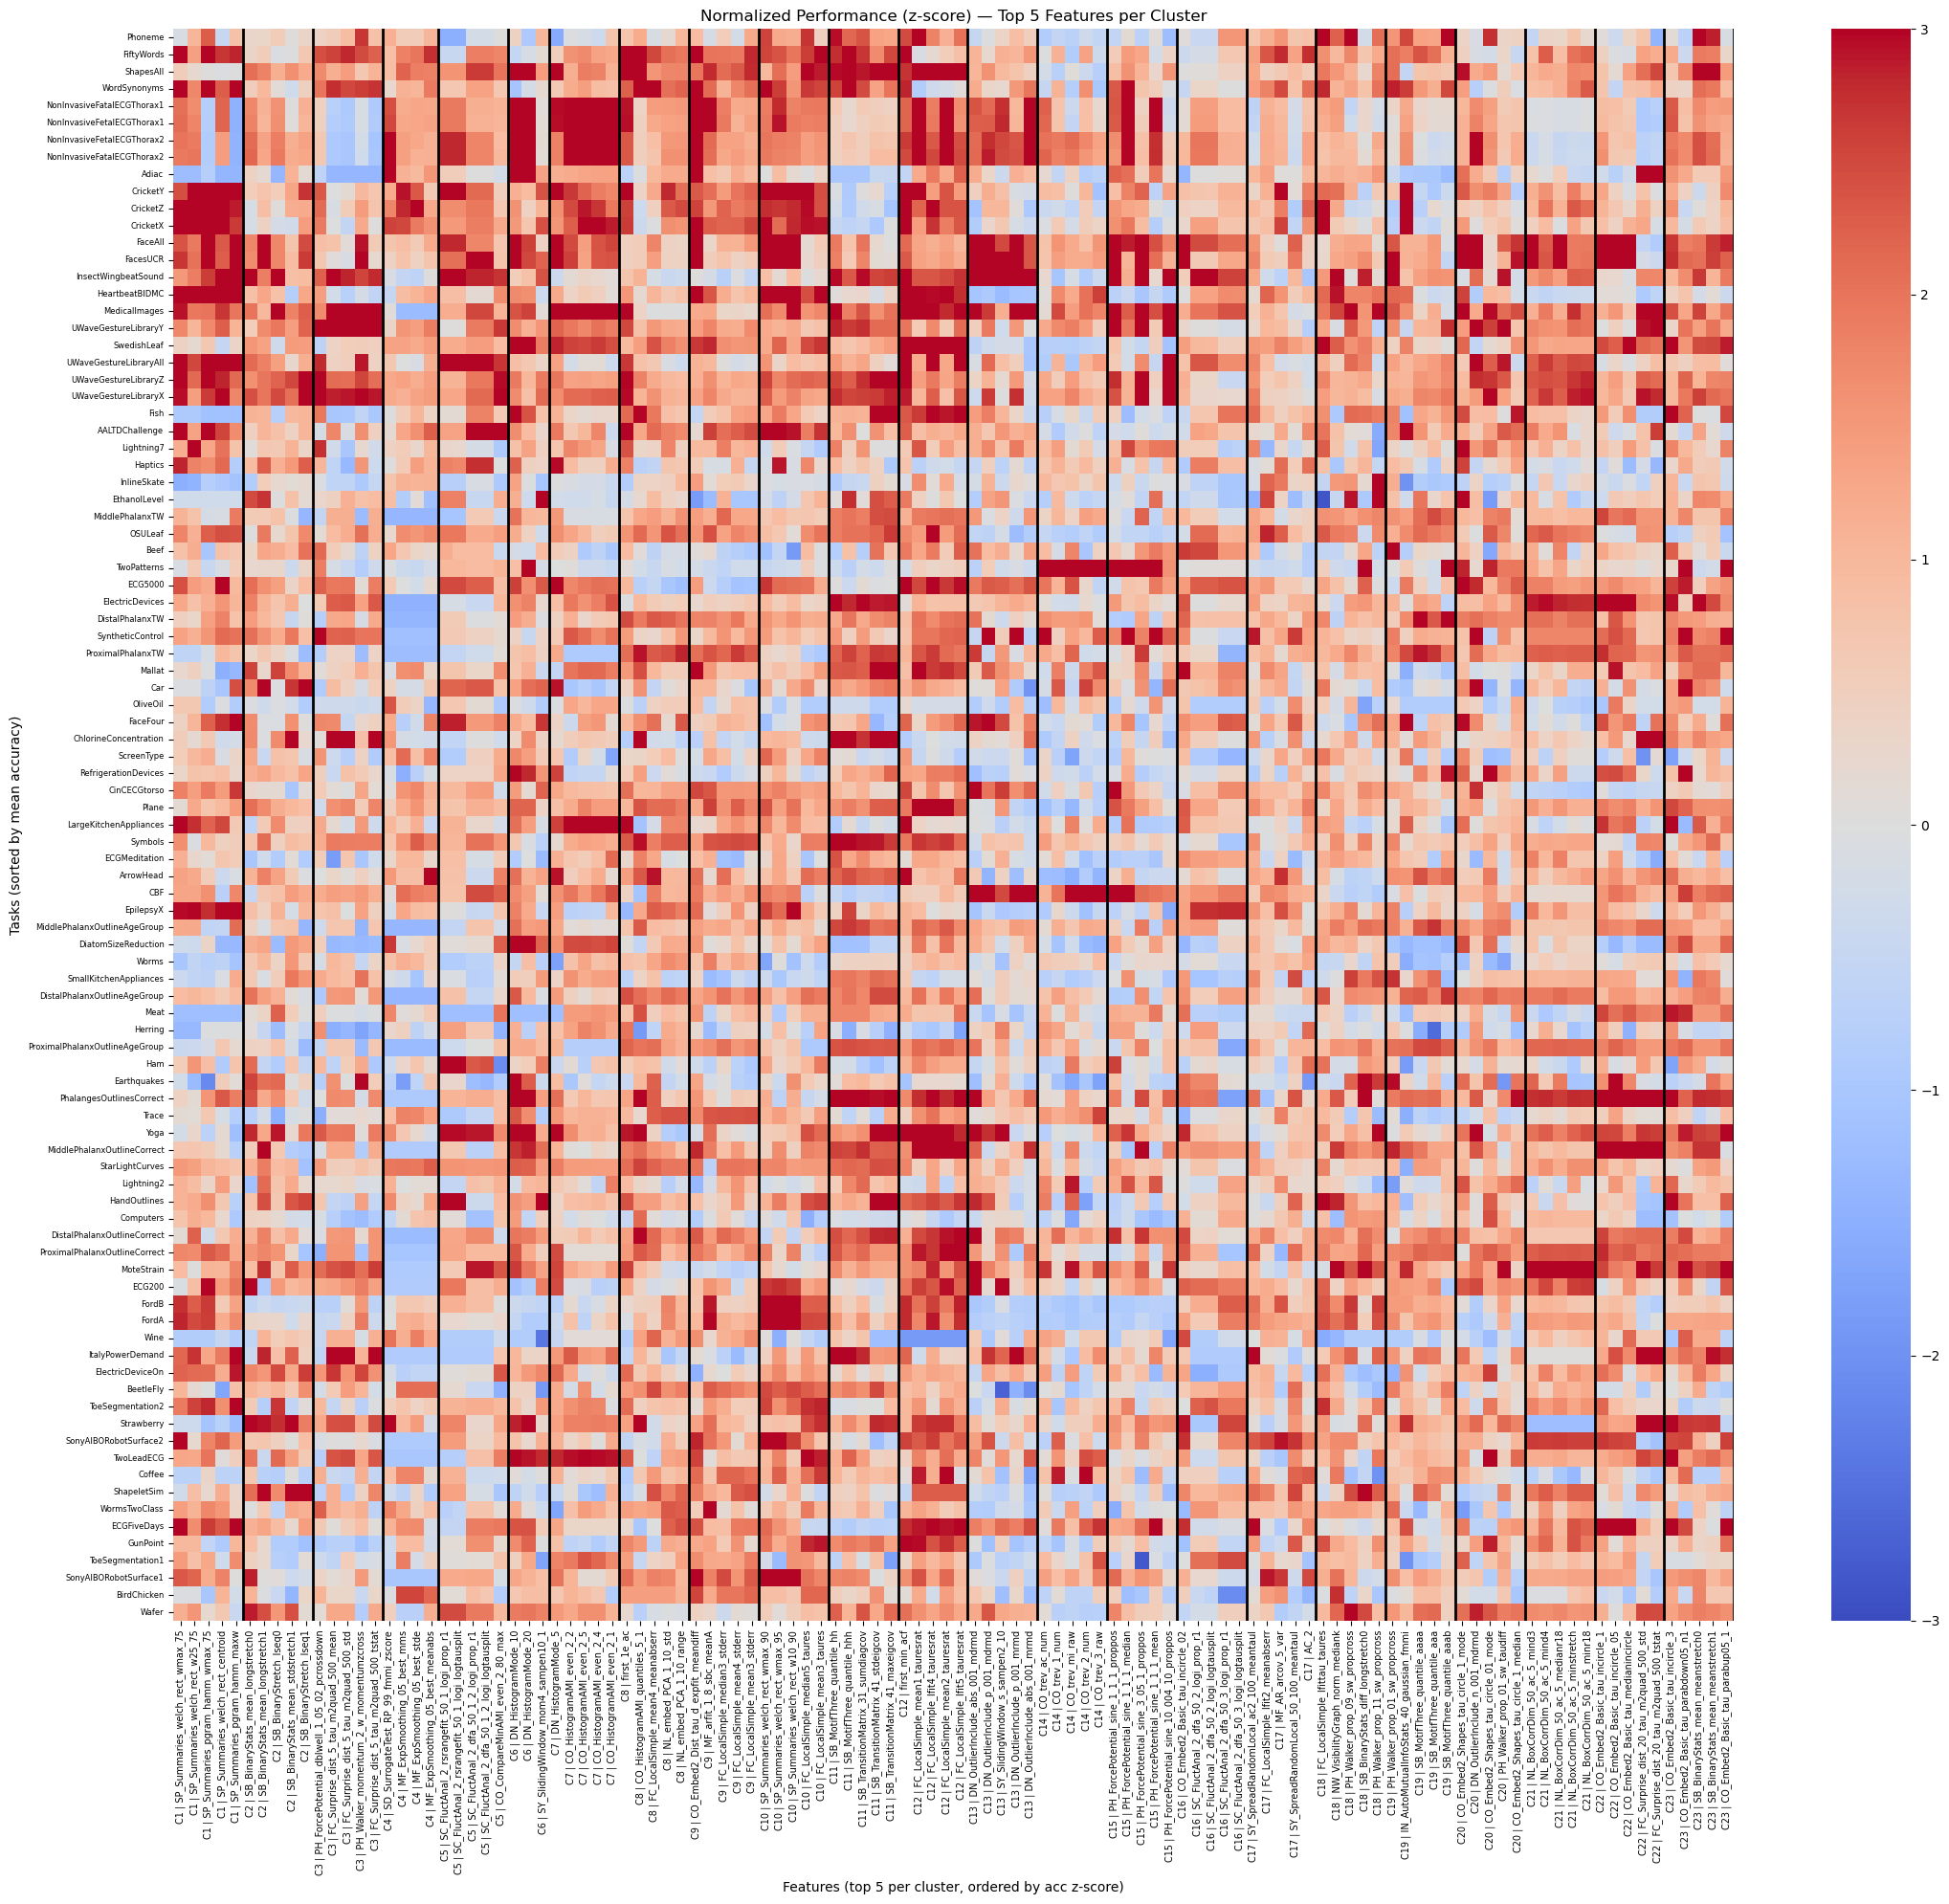

In [78]:
# Heatmap of z-scored performance across tasks and features
#
# X-axis (columns): Top 5 features per cluster, selected by highest acc_z_score
#   within each cluster. Features are grouped by cluster (ascending cluster id),
#   and within each cluster ordered by acc_z_score (best first, left to right).
#   Labels show cluster id and feature name: "C{id} | {feature}".
#
# Y-axis (rows): Tasks sorted by mean raw accuracy across all features
#   (ascending, so hardest tasks at the top, easiest at the bottom).
#   This ordering reflects task complexity.

import seaborn as sns

top_features = []
feature_xlabels = []
for cluster_id in sorted(acc_z_score.keys()):
    scores = acc_z_score[cluster_id].sort_values(ascending=False)
    top5 = scores.head(5).index.tolist()
    top_features.extend(top5)
    feature_xlabels.extend([f"C{cluster_id} | {f}" for f in top5])

# Keep only features present in perf_scores_norm
keep = [i for i, f in enumerate(top_features) if f in perf_scores_norm.columns]
feature_order = [top_features[i] for i in keep]
xlabels = [feature_xlabels[i] for i in keep]

# Build cluster labels for boundary lines
cluster_map = cluster_df.set_index("feature")["cluster"]
cluster_labels = cluster_map.loc[feature_order]

task_order = final_perf_scores.mean(axis=1).sort_values().index

heatmap_data = perf_scores_norm.loc[task_order, feature_order]
n_tasks = len(task_order)

fig, ax = plt.subplots(figsize=(max(20, len(feature_order) * 0.2), max(20, len(task_order) * 0.2)))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, ax=ax,
            xticklabels=xlabels, yticklabels=True, vmin=-3, vmax=3)

# Draw vertical lines at cluster boundaries
x_pos = 0
for cluster_id, group in cluster_labels.groupby(cluster_labels, sort=False):
    x_pos += len(group)
    ax.axvline(x=x_pos, color="black", linewidth=2)

ax.set_xlabel("Features (top 5 per cluster, ordered by acc z-score)")
ax.set_ylabel("Tasks (sorted by mean accuracy)")
ax.set_title("Normalized Performance (z-score) — Top 5 Features per Cluster")
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()

In [54]:
perf_scores_norm.loc[perf_scores_norm.index == "TwoPatterns", "CO_trev_1_num"]

dataset_name
TwoPatterns    8.90059
Name: CO_trev_1_num, dtype: float64

In [52]:
final_perf_scores.loc[final_perf_scores.index == "TwoPatterns", "CO_trev_1_num"]

dataset_name
TwoPatterns    0.743101
Name: CO_trev_1_num, dtype: float64

In [50]:
final_perf_scores.loc[final_perf_scores.index == "TwoPatterns"].sort_values(by="TwoPatterns", axis=1, ascending=False)


,CO_trev_mi_raw,CO_trev_ac_num,CO_trev_3_raw,DK_timerev_3,DK_timerev_4,CO_trev_mi_num,CO_trev_2_raw,DK_timerev_2,CO_trev_ac_raw,CO_trev_1_raw,...,SC_FluctAnal_sign_2_dfa_50_2_logi_se2,SC_FluctAnal_sign_2_dfa_50_2_logi_se1,IN_AutoMutualInfoStats_diff_20_kraskov1_4_pmodeperiodmin,SY_SlidingWindow_ent_s5_2,SC_FluctAnal_sign_2_dfa_50_2_logi_prop_r1,SC_FluctAnal_sign_2_dfa_50_2_logi_logtausplit,SY_RangeEvolve_nuqp20,DN_Withinp_05,CO_CompareMinAMI_std1_2_80_nlocmax,PP_ModelFit_ar_2_rmserrrat_d1
dataset_name,,,,,,,,,,,,,,,,,,,,,
TwoPatterns,0.762556,0.759967,0.757488,0.753743,0.752599,0.752345,0.752121,0.751943,0.750961,0.749171,...,0.229017,0.229017,0.228882,0.228158,0.227277,0.227277,0.226154,0.225973,0.225211,0.225156


In [57]:
cluster_df[cluster_df["feature"] == "CO_trev_mi_raw"]

,feature,cluster
173,CO_trev_mi_raw,14


## Conclusions
1. Cluster 20(without removing mean+std<1 features from normalized accuray) seems to have all features outperforming the mean accuracy for majority of the datasets.
2. DN_HistogramMode_10 has the best combined accuracy, Why- what is this feature? 
3. Clusters whose max combined accuracy is < 1 I think can be ignored for this dataset, because there should be other features which are doing higher than mean on the datasets. (And every features normalized accuracy in these clusters will be less than 1 for all datasets)
4. Some C22 features end up in the same cluster, check their correlation distance
5. After removing mean+std<1 features from normalized accuracy:
   1. we get 18 clusters
   2. And cluster 10 has no feature choosen

## NExt Steps
1. Choose representative features from
   1. clusters 10 - which has no C22 features from it (maybe missing 2 features will be from it)
   2. Cluster 16
2. Analyze model scores with just fit on cluster 20 and DN_HistogramMode_10 single-feature compared to C22 set accuracy
   

# Validation contd.

- fit a decision tree on all c22 features for the the test datasets
  - on raw features
    - catch22 set
    - individual trees per feature
  - on normalized features
    - catch22 set
    - individual trees per feature

In [ ]:
## read data
# all_tasks = pd.read_parquet(
#     Path("../datasets/catch_22/checkpoints/ucr_hctsa_raw_removed.parquet"),
#     filters=[("dataset_name", "in", TEST_DATASETS)],
# )

# all_tasks_n_pf = pd.read_parquet(
#     Path("../datasets/catch_22/checkpoints/ucr_tasks_feat_norm.parquet"),
#     filters=[("dataset_name", "in", TEST_DATASETS)],
# )


In [ ]:
# # raw features: feature set scores
# raw_feat_set_score = calc_feat_set_score_v1(all_tasks, nfolds, feature_cols=CATCH22)

# # raw features: individual scores
# raw_per_feat_score = calc_per_feat_score_v1(all_tasks, nfolds, feature_cols=CATCH22)

# # normalized features: feature set scores
# print("Calculating scores on normalized")
# norm_feat_set_score = calc_feat_set_score_v1(all_tasks_n_pf, nfolds, feature_cols=CATCH22)

# # normalized features: individual scores
# norm_per_feat_score = calc_per_feat_score_v1(all_tasks_n_pf, nfolds, feature_cols=CATCH22)

(28, 20)
(1004, 20)
dname='ECGMeditation'
dname='EthanolLevel'
Calculating scores on normalized
(28, 20)
(1004, 20)
dname='ECGMeditation'
dname='EthanolLevel'



- accuracy of catch22 lower by a relative difference of 37% for the dataset 'EthanolLevel'; 50.2% full vs 31.8% catch22
- The reduced set gave better mean performance in only a small number of cases: e.g., for 'ECGMeditation' with 60% full vs 81.2% catch22; given that this dataset contained just 28 time series and had a high standard deviation in accuracies of the full set between folds (35.3%), the performance might not be significantly increased

# What could be missing to give such different numbers for ECG data:
1. could be missing two features?
2. balanced accuracy metric used or not or some other parameter different in dtree fit

In [ ]:
# without balanced weight
raw_feat_set_score_unbal = calc_feat_set_score_v1(
    all_tasks_n_pf, nfolds, feature_cols=CATCH22, class_weight=None
)
raw_feat_set_score_unbal

(1004, 20)
(28, 20)


,0,1,2,3,4,5,6,7,8,9
ECGMeditation,0.666667,1.000000,0.166667,0.666667,1.00,0.333333,0.666667,1.00,NaN,NaN
EthanolLevel,0.305385,0.424615,0.228077,0.318846,0.46,0.480000,0.390000,0.42,0.39,0.37


In [48]:
raw_feat_set_score_unbal.mean(axis=1)

ECGMeditation    0.687500
EthanolLevel     0.378692
dtype: float64

In [49]:
raw_feat_set_score_unbal.std(axis=1)

ECGMeditation    0.314182
EthanolLevel     0.076494
dtype: float64

In [50]:
all_tasks_n_pf.groupby(["dataset_name", "label"]).size()

dataset_name   label
ECGMeditation  0          8
               1         11
               2          9
EthanolLevel   0        252
               1        250
               2        252
               3        250
dtype: int64

## Conflusions 
1. normalization doesn't affect accuracy in any meaningful quantity
2. not much difference in balanced vs unbalanced class weights for ECG/Ethanol dataset - bcz these datasets are balanced
3. what will be change in accuracy on C22 set if we recalculate the missing features

### Reproduce total figure
"Using the diverse canonical catch22 feature-subset, the mean class-balanced accuracy across all datasets, $a^{tot}$, of catch22 was ∼72%, a small reduction relative to the ∼77% achieved when computing all 4791 features. See Fig. 4A for a dataset-by-dataset scatter."


In [ ]:
all_tasks_n_pf = pd.read_parquet(
    Path("../datasets/catch_22/checkpoints/ucr_tasks_feat_norm.parquet"),
    # filters=[("dataset_name", "in", TEST_DATASETS)],
)


In [85]:
all_tasks_n_pf.loc[all_tasks_n_pf["dataset_name"] == TEST_DATASETS[0], CATCH22].isna().sum().sort_values()

DN_HistogramMode_5                                0
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1       0
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1            0
CO_Embed2_Dist_tau_d_expfit_meandiff              0
FC_LocalSimple_mean1_tauresrat                    0
SB_MotifThree_quantile_hh                         0
SB_BinaryStats_diff_longstretch0                  0
MD_hrv_classic_pnn40                              0
SB_TransitionMatrix_3ac_sumdiagcov                0
CO_HistogramAMI_even_2_5                          0
FC_LocalSimple_mean3_stderr                       0
SP_Summaries_welch_rect_area_5_1                  0
DN_OutlierInclude_n_001_mdrmd                     0
DN_OutlierInclude_p_001_mdrmd                     0
SB_BinaryStats_mean_longstretch1                  0
DN_HistogramMode_10                               0
CO_trev_1_num                                     0
PD_PeriodicityWang_th0.01                         0
IN_AutoMutualInfoStats_40_gaussian_fmmi        1004
SP_Summaries

In [62]:
all_tasks_n_pf.head()

,DN_HistogramMode_5,DN_HistogramMode_10,DN_HistogramMode_20,maximum,miminmum,DN_Moments_3,DN_Moments_4,DN_Moments_5,DN_Moments_6,DN_Moments_7,...,SD_SurrogateTest_RP_99_o3_f,SD_SurrogateTest_RP_99_o3_mediqr,SD_SurrogateTest_RP_99_o3_prank,SD_SurrogateTest_RP_99_tc3_p,SD_SurrogateTest_RP_99_tc3_zscore,SD_SurrogateTest_RP_99_tc3_f,SD_SurrogateTest_RP_99_tc3_mediqr,SD_SurrogateTest_RP_99_tc3_prank,label,dataset_name
0,0.682927,0.257862,0.230530,1.000000,0.491344,0.709929,0.980797,0.998851,0.984621,1.000000,...,0.0,0.449212,0.0,0.028394,0.750763,0.092673,0.572838,0.000000,NaN,AALTDChallenge
1,0.560976,0.235849,0.230530,0.947506,0.483765,0.557462,0.738069,0.741099,0.706799,0.711831,...,0.0,0.285522,0.0,0.077757,0.628614,0.213148,0.518303,0.040816,NaN,AALTDChallenge
2,0.585366,0.477987,0.246106,0.589657,0.664141,0.342988,0.233029,0.256625,0.143823,0.153158,...,0.0,0.335512,0.0,0.307439,0.409127,0.485245,0.303945,0.285714,NaN,AALTDChallenge
3,0.292683,0.330189,0.102804,0.668710,0.903405,0.680493,0.398358,0.586884,0.294869,0.366774,...,0.0,0.578592,0.0,0.042633,0.704568,0.174863,0.724877,0.081633,NaN,AALTDChallenge
4,0.439024,0.059748,0.121495,0.519520,0.543285,0.430536,0.287557,0.398585,0.216064,0.245035,...,0.0,0.303216,0.0,0.302671,0.412132,0.496035,0.292382,0.306122,NaN,AALTDChallenge


In [ ]:
def calc_feat_set_score_v1(
    task_df: pd.DataFrame,
    nfolds: pd.DataFrame,
    feature_cols: List[str],
    class_weight: Optional[str] = "balanced",
) -> pd.DataFrame:
    if not feature_cols:
        feature_cols = [col for col in task_df.columns if col not in ["label", "dataset_name"]]

    # Pre-compute as dict to avoid DataFrame serialization issues in worker processes
    nfolds_dict = dict(zip(nfolds["dataset_name"], nfolds["nfolds"]))

    datasets = list(task_df.groupby(["dataset_name"]))
    total = len(datasets)

    def _score_dataset(idx, total, dname, data, nfolds_dict, feature_cols, class_weight):
        print(f"[{idx + 1}/{total}] Processing: {dname}")
        n_cv = nfolds_dict[dname]
        cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=23)
        y = data["label"]
        X = data[feature_cols]
        clf = tree.DecisionTreeClassifier(class_weight=class_weight, random_state=23)
        return dname, cross_val_score(clf, X, y, cv=cv, scoring=make_scorer(balanced_accuracy_score))

    results = Parallel(n_jobs=-1)(
        delayed(_score_dataset)(idx, total, dname, data, nfolds_dict, feature_cols, class_weight)
        for idx, ((dname,), data) in enumerate(datasets)
    )

    actual_scores = dict(results)

    return pd.DataFrame.from_dict(actual_scores, orient="index")


nfolds = fs.num_of_folds(all_tasks_n_pf)
raw_feat_set_score = calc_feat_set_score_v1(
    all_tasks_n_pf, nfolds, feature_cols=CATCH22, class_weight="balanced"
)

python(18201) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18202) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18203) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18204) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18205) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18206) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18207) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18208) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18209) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18210) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[8/93] Processing: Car[5/93] Processing: BeetleFly

[4/93] Processing: Beef
[6/93] Processing: BirdChicken
[2/93] Processing: Adiac
[7/93] Processing: CBF
[3/93] Processing: ArrowHead
[1/93] Processing: AALTDChallenge
[11/93] Processing: Coffee
[9/93] Processing: ChlorineConcentration
[10/93] Processing: CinCECGtorso
[12/93] Processing: Computers
[13/93] Processing: CricketX
[14/93] Processing: CricketY
[15/93] Processing: CricketZ
[16/93] Processing: DiatomSizeReduction
[17/93] Processing: DistalPhalanxOutlineAgeGroup
[18/93] Processing: DistalPhalanxOutlineCorrect
[19/93] Processing: DistalPhalanxTW
[20/93] Processing: ECG200
[21/93] Processing: ECG5000
[22/93] Processing: ECGFiveDays
[23/93] Processing: ECGMeditation
[24/93] Processing: Earthquakes
[25/93] Processing: ElectricDeviceOn
[26/93] Processing: ElectricDevices
[27/93] Processing: EpilepsyX
[28/93] Processing: EthanolLevel
[29/93] Processing: FaceAll
[30/93] Processing: FaceFour
[31/93] Processing: FacesUCR
[32/93] Processi

In [ ]:
raw_feat_set_score.mean(axis=1)[TEST_DATASETS[0]]  # .mean()

np.float64(0.3687692307692308)

In [88]:
all_tasks_n_pf.shape

(147198, 6377)

In [ ]:
all_feat_cols = [col for col in all_tasks_n_pf if col not in ["dataset_name", "label"]]
raw_full_feat_set_score = calc_feat_set_score_v1(
    all_tasks_n_pf[all_tasks_n_pf["dataset_name"].isin(TEST_DATASETS)],
    nfolds,
    feature_cols=all_feat_cols,
    class_weight="balanced",
)

python(21748) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21749) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21750) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21751) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21752) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21753) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21754) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21755) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21756) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(21757) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[1/2] Processing: ECGMeditation
[2/2] Processing: EthanolLevel


In [ ]:
raw_full_feat_set_score.mean(axis=1)[TEST_DATASETS]  # .mean()

EthanolLevel     0.493962
ECGMeditation    0.562500
dtype: float64

In [93]:
raw_feat_set_score.mean(axis=1)[TEST_DATASETS]

EthanolLevel     0.368769
ECGMeditation    0.645833
dtype: float64

In [ ]:
# Plot perf scores


In [138]:
top_performers

DN_HistogramMode_10                           1.219524
CO_Embed2_Dist_tau_d_expfit_meandiff          1.212353
first_min_acf                                 1.207505
FC_LocalSimple_mean1_tauresrat                1.197293
FC_LocalSimple_lfit4_tauresrat                1.184053
                                                ...   
SB_TransitionpAlphabet_20_ac_maxdiagfexp_b    0.965187
MD_hrv_classic_pnn20                          0.965161
CO_fzcglscf_5_5                               0.965097
EN_SampEn_5_01_sampen1                        0.964884
FC_Surprise_dist_5_1_m2quad_500_mean          0.964665
Length: 710, dtype: float64

In [110]:
perf_scores_norm

,DN_HistogramMode_5,DN_HistogramMode_10,DN_HistogramMode_20,DN_Moments_3,DN_Moments_4,DN_Moments_5,DN_Moments_6,DN_Moments_7,DN_Moments_8,DN_Moments_9,...,MD_hrv_classic_pnn20,MD_hrv_classic_pnn30,MD_hrv_classic_pnn40,MD_hrv_classic_lfhf,MD_hrv_classic_hf,MD_hrv_classic_SD2,CP_ML_StepDetect_l1pwc_10_E,CP_ML_StepDetect_l1pwc_10_rmsoff,SD_SurrogateTest_RP_99_fmmi_zscore,SD_SurrogateTest_RP_99_fmmi_mediqr
dataset_name,,,,,,,,,,,,,,,,,,,,,
AALTDChallenge,1.130689,1.274766,0.955291,0.814347,0.789290,0.710987,0.710987,0.801818,0.779893,1.030462,...,1.055518,1.387521,1.165142,1.042990,1.111896,1.187067,1.046122,0.920838,0.914574,1.465824
Adiac,1.156103,2.399459,3.395598,1.188823,1.316067,1.112476,1.181552,1.243356,1.319703,1.148832,...,1.199730,1.246992,1.246992,0.945241,0.879802,1.286983,1.396049,1.261534,2.904800,0.483527
ArrowHead,1.302141,1.217664,1.020906,0.944545,1.101392,0.723308,0.999754,0.840112,0.982725,0.814304,...,0.808982,1.078643,1.040063,1.305467,1.352162,1.086226,1.044586,1.029021,1.128132,1.161125
Beef,1.232053,0.889816,0.992487,0.958264,1.334725,1.026711,1.060935,0.889816,1.163606,1.095159,...,0.992487,1.026711,1.095159,0.924040,0.342237,0.787145,1.060935,1.368948,1.232053,1.129382
BeetleFly,1.034741,0.919769,0.919769,1.303007,0.881446,1.264683,0.996417,1.341330,1.111388,1.303007,...,1.073064,0.804798,1.073064,1.073064,1.073064,1.226359,0.958093,1.188036,0.881446,1.111388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wine,0.889176,0.813202,0.844155,0.928570,0.959522,1.055193,1.043938,1.088959,1.077704,1.139609,...,0.894804,0.818830,0.810388,0.877921,0.863851,1.229652,1.086146,1.038310,1.246535,0.970778
WordSynonyms,1.006354,0.627512,0.866729,0.902807,0.724178,0.825568,0.790060,0.804754,0.755820,0.944786,...,0.776511,0.676106,0.885656,0.863609,1.032914,0.997728,0.826293,0.955149,0.860498,0.853051
Worms,0.513626,0.842477,1.036916,0.921722,1.025838,0.953488,0.987233,0.932236,0.947553,0.878313,...,1.077896,1.044264,0.959536,0.957841,1.212082,1.066761,1.108870,1.044999,1.008655,0.949306


# Clustering features
- plot cluster mean accuracy and feature accuracy

In [134]:
len(top_performers)

710

26 clusters from 710 features
                              feature  cluster
176  SP_Summaries_pgram_hamm_centroid        1
437      SP_Summaries_welch_rect_maxw        1
126   SP_Summaries_pgram_hamm_wmax_75        1
86   SP_Summaries_welch_rect_centroid        1
141      SP_Summaries_pgram_hamm_maxw        1
..                                ...      ...
361        SB_TransitionMatrix_3ac_T8       26
124        SB_TransitionMatrix_2ac_T4       26
123   CO_Embed2_Basic_tau_incircle_05       26
155   SB_TransitionMatrix_3ac_symdiff       26
577   SB_TransitionMatrix_5ac_symdiff       26

[710 rows x 2 columns]


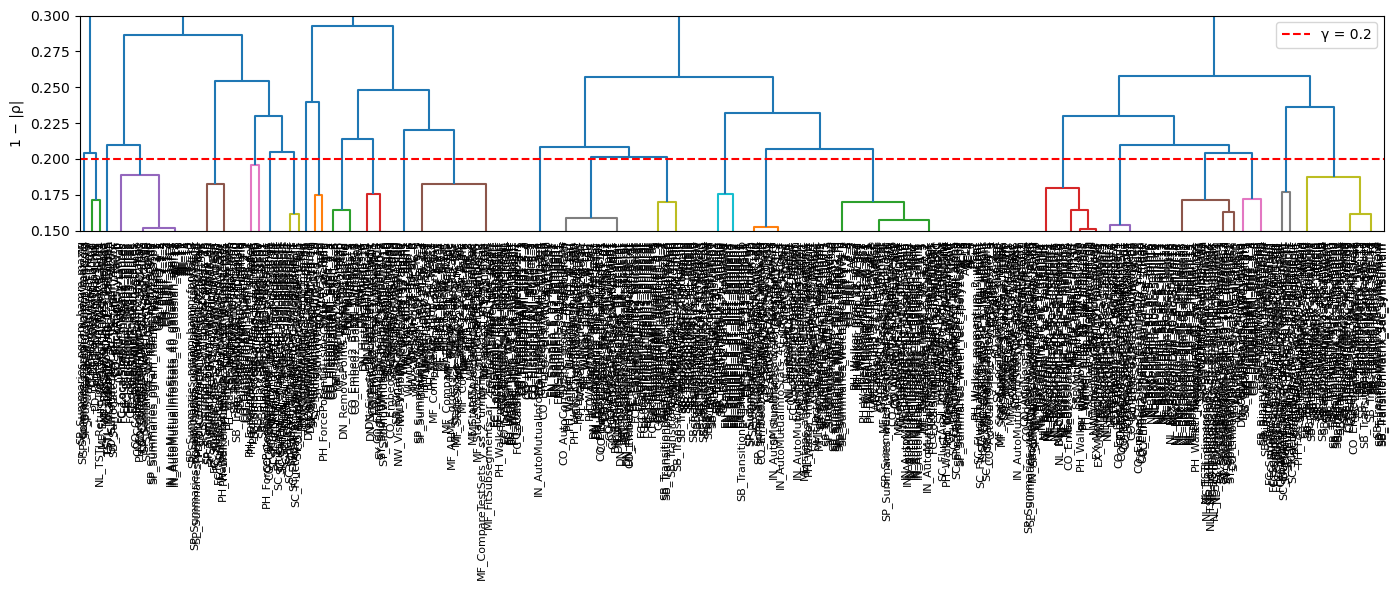

In [ ]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform

nf = len(top_performers)
gamma = 0.2
# 1. absolute Pearson correlation → distance
corr = new_perf_scores[list(top_performers.index)[:nf]].corr()
dist = 1 - corr.abs().copy()
# np.fill_diagonal(dist.values, 0)          # ensure exact zeros on diagonal
dist = dist.clip(lower=0)  # handle floating-point negatives

# 2. condensed distance matrix (upper triangle, no diagonal)
condensed = squareform(dist, checks=False)

# 3. hierarchical clustering — complete linkage
Z = linkage(condensed, method="complete")

# 4. cut tree at distance threshold γ
clusters = fcluster(Z, t=gamma, criterion="distance")

# 5. summary
cluster_df = pd.DataFrame({"feature": list(top_performers.index)[:nf], "cluster": clusters})
print(f"{cluster_df['cluster'].nunique()} clusters from {len(cluster_df)} features")
print(cluster_df.sort_values("cluster"))

# 6. (optional) dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    labels=top_performers.index.tolist()[:nf],
    ax=ax,
    color_threshold=gamma,
    leaf_rotation=90,
    leaf_font_size=8,
)
ax.axhline(gamma, ls="--", color="red", label=f"γ = {gamma}")
ax.set_ylim(0.15, 0.3)
ax.set_ylabel("1 − |ρ|")
ax.legend()
plt.tight_layout()
plt.show()

In [97]:
cluster_df

,feature,cluster
0,DN_HistogramMode_5,6
1,DN_HistogramMode_10,6
2,DN_HistogramMode_20,6
3,first_zero_ac,3
4,first_1e_ac,3
...,...,...
147,NL_embed_PCA_1_10_perc_1,4
148,NL_embed_PCA_1_10_std,4
149,NL_embed_PCA_1_10_range,4
150,MF_hmm_08_2_maxP,7


In [102]:
perf_scores_norm_comb

DN_HistogramMode_5                    1.114230
DN_HistogramMode_10                   1.219524
DN_HistogramMode_20                   1.167373
DN_Moments_3                          0.956561
DN_Moments_4                          0.975259
                                        ...   
MD_hrv_classic_SD2                    1.053335
CP_ML_StepDetect_l1pwc_10_E           0.975999
CP_ML_StepDetect_l1pwc_10_rmsoff      1.007344
SD_SurrogateTest_RP_99_fmmi_zscore    0.991936
SD_SurrogateTest_RP_99_fmmi_mediqr    0.991498
Length: 984, dtype: float64

In [105]:
new_perf_scores[CATCH22].mean(axis=1)

dataset_name
AALTDChallenge    0.277579
Adiac             0.123514
ArrowHead         0.502073
Beef              0.311500
BeetleFly         0.613750
                    ...   
Wine              0.549583
WordSynonyms      0.096839
Worms             0.488695
WormsTwoClass     0.610734
Yoga              0.586688
Length: 93, dtype: float64

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

score_df = new_perf_scores
mean_accuracy = {}
c22_cluster_scores = {}

for cluster, df in cluster_df.groupby("cluster"):
    cluster_scores = score_df[df["feature"]]  # datasets × features
    row_mean = cluster_scores.mean(axis=1)  # mean across features per dataset
    normalized = cluster_scores.div(row_mean, axis=0)  # normalize per dataset
    mean_accuracy[cluster] = normalized.mean(axis=0)  # mean across datasets per feature

    # Collect CATCH22 features in this cluster
    c22_in_cluster = [f for f in df["feature"] if f in CATCH22]
    if c22_in_cluster:
        c22_cluster_scores[cluster] = normalized[c22_in_cluster].mean(axis=0)

import plotly.express as px

heatmap_df = pd.DataFrame(mean_accuracy)
heatmap_df.columns = [f"Cluster {c}" for c in heatmap_df.columns]
heatmap_df = heatmap_df.sort_index()

In [137]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Box plots of cluster accuracies across datasets
for col in heatmap_df.columns:
    fig.add_trace(
        go.Box(y=heatmap_df[col], name=col, showlegend=False),
        secondary_y=False,
    )

# Individual catch22 feature normalized accuracy from c22_cluster_scores
for cluster, scores in c22_cluster_scores.items():
    fig.add_trace(
        go.Scatter(
            x=[f"Cluster {cluster}"] * len(scores),
            y=scores.values,
            mode="markers+text",
            name="Catch22 Features",
            showlegend=(cluster == list(c22_cluster_scores.keys())[0]),
            marker=dict(color="red", size=10, symbol="diamond"),
            text=scores.index,
            textposition="top center",
            textfont=dict(size=8),
        ),
    )

fig.update_layout(
    title="Cluster Accuracy Distribution with Catch22 Feature Positions",
    xaxis_title="Cluster",
    width=1100,
    height=600,
)
fig.update_yaxes(title_text="Normalized Accuracy", secondary_y=False)
fig.show()

In [ ]:
import plotly.graph_objects as go

sorted_scores = perf_scores_norm_comb.sort_values().reset_index()
sorted_scores.columns = ["feature", "score"]
sorted_scores["is_C22"] = sorted_scores["feature"].isin(fs.CATCH22)

other = sorted_scores[~sorted_scores["is_C22"]]
c22 = sorted_scores[sorted_scores["is_C22"]]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=other.index,
        y=other["score"],
        mode="markers",
        marker=dict(size=4, color="lightgrey"),
        text=other["feature"],
        hoverinfo="text+y",
        name="Other",
    )
)
fig.add_trace(
    go.Scatter(
        x=c22.index,
        y=c22["score"],
        mode="markers",
        marker=dict(size=10, color="red", symbol="diamond"),
        text=c22["feature"],
        hoverinfo="text+y",
        name="C22",
    )
)

fig.update_layout(
    width=1000,
    height=800,
    xaxis=dict(
        title="Feature Rank",
        tickvals=c22.index.tolist(),
        ticktext=c22["feature"].tolist(),
        tickangle=90,
        tickfont=dict(size=10),
    ),
    yaxis_title="Combined Accuracy",
    hovermode="closest",
)